# Image Classification

## Basic Concept


### The classification pipeline

```mermaid
flowchart TD
    A["Dataset<br/>(images + labels)"] --> B["Augment<br/>(random transforms)"]
    B --> C["Normalise<br/>(mean/std)"]
    C --> D["DataLoader<br/>(batch + shuffle)"]
    D --> E["Model<br/>(CNN)"]
    E --> F["Logits<br/>(N, C)"]
    F --> G["Cross-entropy loss"]
    F --> H["Argmax<br/>at eval"]
    G --> I["Backward"]
    I --> J["Optimizer step"]
    J --> K["Scheduler step"]
    K --> E

    style A fill:#dbeafe,stroke:#2563eb
    style E fill:#fef3c7,stroke:#d97706
    style G fill:#fecaca,stroke:#dc2626
    style H fill:#dcfce7,stroke:#16a34a
```

### Augmentation

A CNN has inductive bias for translation (from weight sharing) but no built-in invariance to crops, flips, colour jitter, or occlusion. The only way to teach it those invariances is to show it pixels that exercise them. Every random transform during training is a way of saying: **"these two images have the same label; learn the features that ignore the difference."**

#### Normal Ways

```
Original crop:  "dog facing left"
Flip:           "dog facing right"       <- same label, different pixels
Rotate(+15):    "dog, slight tilt"
Colour jitter:  "dog in warmer light"
RandomErasing:  "dog with patch missing"
```

#### Mixup and cutmix

Ordinary augmentation transforms pixels but keeps labels one-hot. **Mixup** and **cutmix** break that by interpolating both.

```
Mixup:
  lambda ~ Beta(a, a)
  x = lambda * x_i + (1 - lambda) * x_j
  y = lambda * y_i + (1 - lambda) * y_j

Cutmix:
  paste a random rectangle of x_j into x_i
  y = area-weighted mix of y_i and y_j
```

Why it helps: **the model stops memorising spiky one-hot targets and learns to interpolate between classes.** Training loss goes up, test accuracy goes up. It is the single cheapest robustness upgrade for any classifier.

# Build your Own

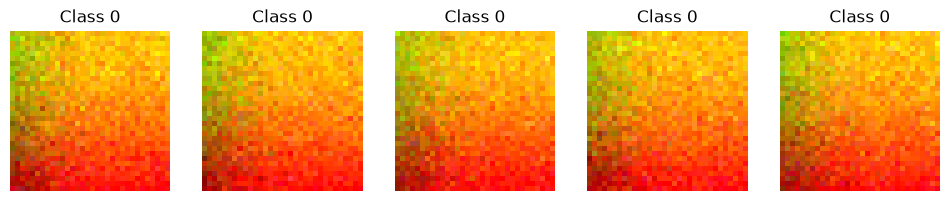

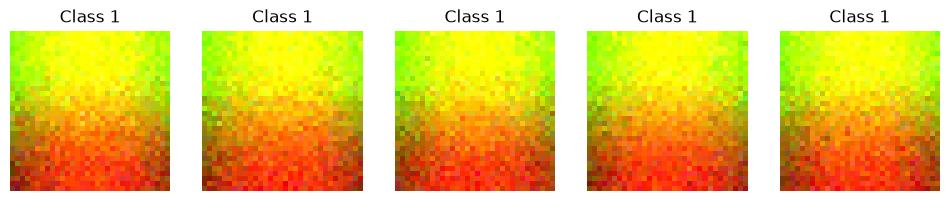

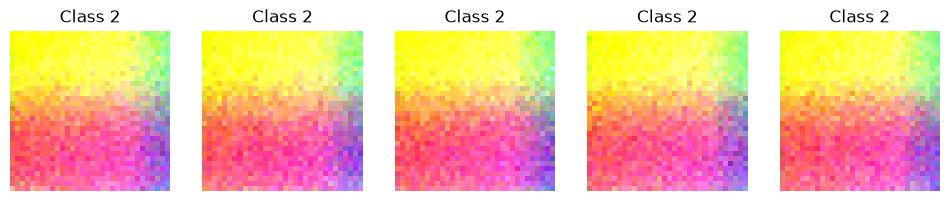

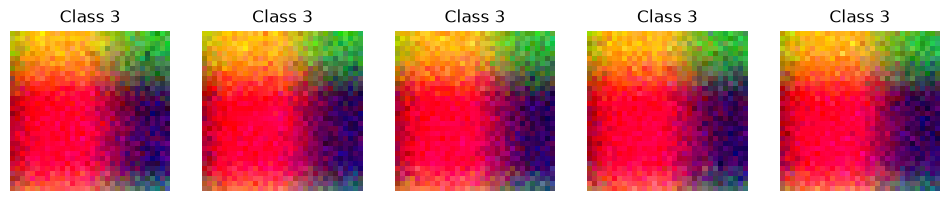

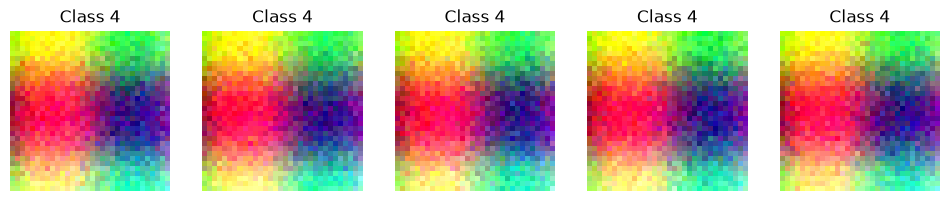

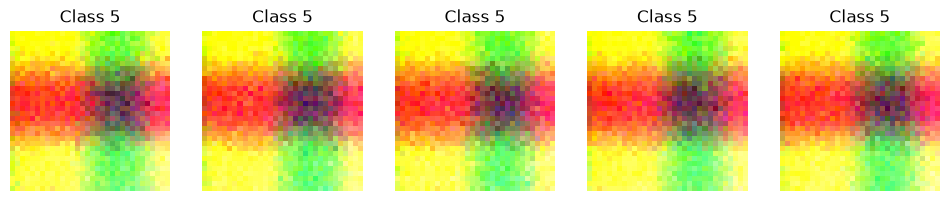

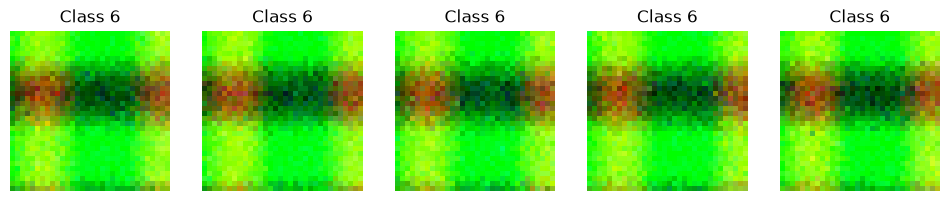

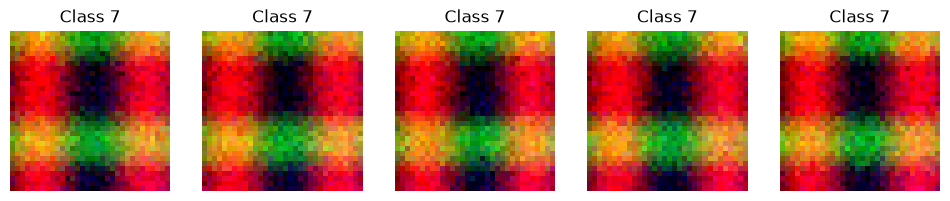

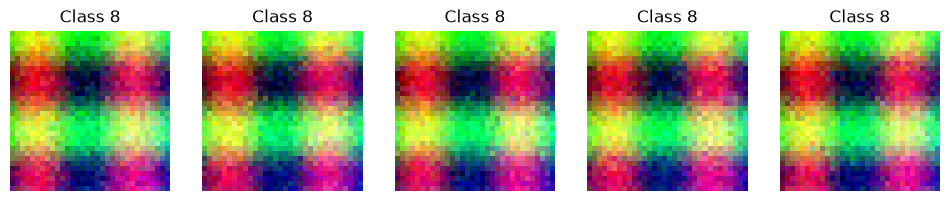

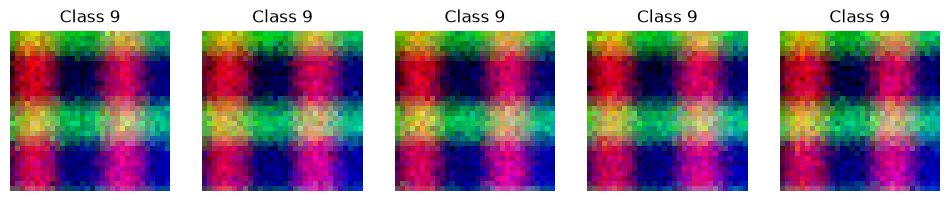

In [4]:
import numpy as np
import torch
from torch.utils.data import Dataset

%matplotlib inline
import matplotlib.pyplot as plt

def synthetic_cifar(num_per_class=1000, num_classes=10, seed=0):
    rng = np.random.default_rng(seed)

    X = []
    Y = []
    for c in range(num_classes):
        centre = rng.uniform(0, 1, (3,))
        freq = 2 + c
        for _ in range(num_per_class):
            yy, xx = np.meshgrid(np.linspace(0, 1, 32), np.linspace(0, 1, 32), indexing="ij")

            r = np.sin(xx * freq) * 0.5 + centre[0]
            g = np.cos(yy * freq) * 0.5 + centre[1]
            b = (xx + yy) * 0.5 * centre[2]

            img = np.stack([r, g, b], axis=-1)
            img += rng.normal(0, 0.08, img.shape)
            img = np.clip(img, 0, 1)
            
            X.append(img.astype(np.float32))
            Y.append(c)

        fig, axs = plt.subplots(1, 5, figsize=(12, 4))
        for i in range(5):
            axs[i].imshow(X[-(i + 1)])
            axs[i].set_title(f"Class {Y[-(i + 1)]}")
            axs[i].axis("off")
        plt.show()

    # 将X和Y转换为numpy数组
    X = np.stack(X)
    Y = np.array(Y)
    # 打乱顺序
    idx = rng.permutation(len(X))

    return X[idx], Y[idx]

class ArrayDataset(Dataset):
    def __init__(self, X, Y, transform=None):
        self.X = X
        self.Y = Y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        img = self.X[i]
        if self.transform is not None:
            img = self.transform(img)
        img = torch.from_numpy(img).permute(2, 0, 1)
        return img, int(self.Y[i])

X, Y =synthetic_cifar()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].


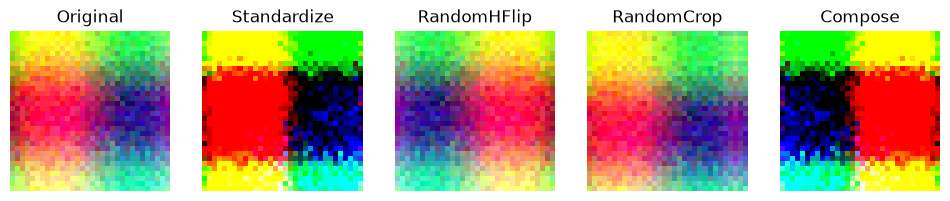

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].


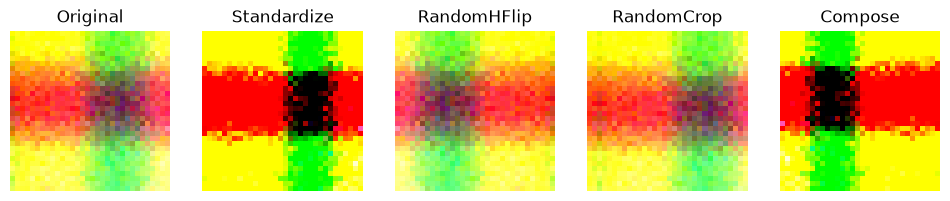

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].


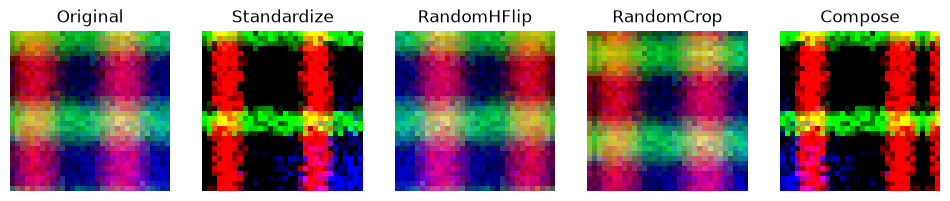

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].


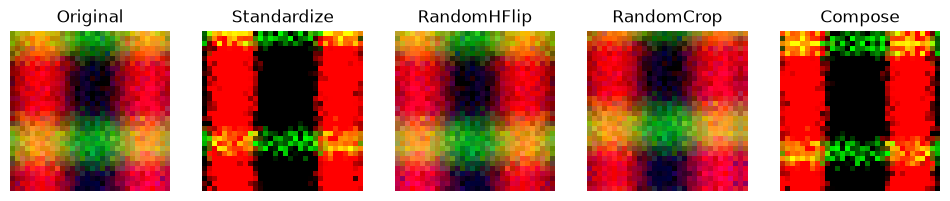

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0..2.0].


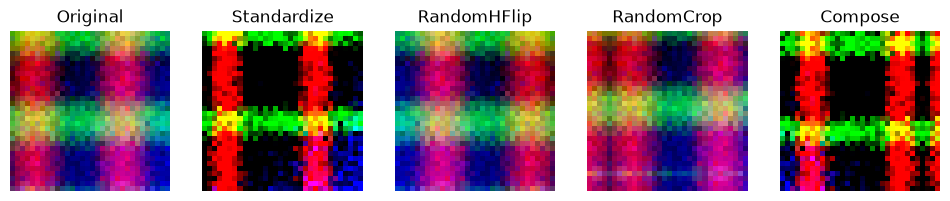

In [17]:
def standardize(mean, std):
    mean = np.array(mean, dtype=np.float32)
    std = np.array(std, dtype=np.float32)

    def _fn(img):
        return (img - mean) / std
    return _fn

def random_hflip(p = 0.5):
    def _fn(img):
        if np.random.random() < p:
            return img[:, ::-1, :].copy()
        return img
    return _fn

def random_crop(pad=4):
    def _fn(img):
        h, w = img.shape[:2]
        padded = np.pad(img, ((pad, pad), (pad, pad), (0, 0)), mode="reflect")
        x = np.random.randint(0, 2 * pad)
        y = np.random.randint(0, 2 * pad)
        return padded[y:y+h, x:x+w, :]
    return _fn

def compose(*fns):
    def _fn(img):
        for fn in fns:
            img = fn(img)
        return img
    return _fn
mean = [0.5, 0.5, 0.5]
std = [0.25, 0.25, 0.25]
MODES = {
    "Original": "PlaceHolder",
    "Standardize": standardize(mean, std),
    "RandomHFlip": random_hflip(1.0),
    "RandomCrop": random_crop(4),
    "Compose": compose(
        random_crop(4),
        standardize(mean, std),
        random_hflip(1.0),
    )
}

test_imgs = X[:5]
for img in test_imgs:
    fig, axs = plt.subplots(1, 5, figsize=(12, 4))
    for i, (k, fn) in enumerate(MODES.items()):
        if k != "Original":
            aug_img = fn(img)
        else:
            aug_img = img

        axs[i].imshow(aug_img)
        axs[i].set_title(k)
        axs[i].axis("off")
    plt.show()


In [13]:
def mixup_batch(x, y, num_classes, alpha=0.2):
    if alpha <= 0:
        return x, torch.nn.functional.one_hot(y, num_classes).float()
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(x.size(0), device=x.device)
    x_mixed = lam * x + (1 - lam) * x[idx]
    y_onehot = torch.nn.functional.one_hot(y, num_classes).float()
    y_mixed = lam * y_onehot + (1 - lam) * y_onehot[idx]
    return x_mixed, y_mixed

In [14]:
def soft_cross_entropy(logits, soft_targets):
    log_probs = torch.log_softmax(logits, dim=-1)
    return -(soft_targets * log_probs).sum(dim=-1).mean()

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR

def train_one_epoch(model, loader, optimizer, device, num_classes, use_mixup=True):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if use_mixup:
            x_m, y_soft = mixup_batch(x, y, num_classes)
            logits = model(x_m)
            loss = soft_cross_entropy(logits, y_soft)
        else:
            logits = model(x)
            loss = nn.functional.cross_entropy(logits, y, label_smoothing=0.1)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        total += x.size(0)
        # Training accuracy vs the un-mixed labels `y` is only an approximation
        # when mixup is on (the model saw soft targets, not y). Treat it as a
        # rough progress signal; rely on val accuracy for real performance.
        with torch.no_grad():
            pred = logits.argmax(dim=-1)
            correct += (pred == y).sum().item()
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, device, num_classes):
    model.eval()
    total, correct = 0, 0
    loss_sum = 0.0
    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = nn.functional.cross_entropy(logits, y)
        pred = logits.argmax(dim=-1)
        for t, p in zip(y.cpu(), pred.cpu()):
            cm[t, p] += 1
        loss_sum += loss.item() * x.size(0)
        total += x.size(0)
        correct += (pred == y).sum().item()
    return loss_sum / total, correct / total, cm

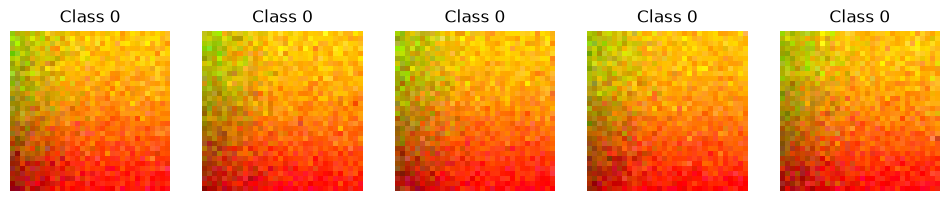

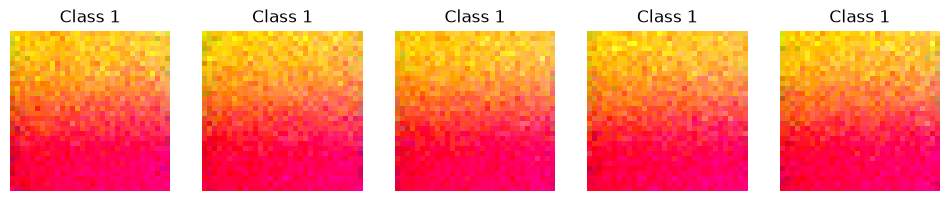

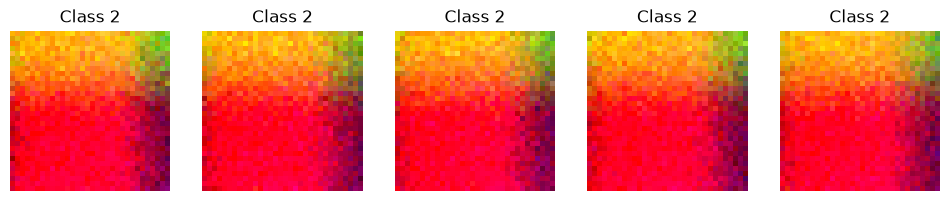

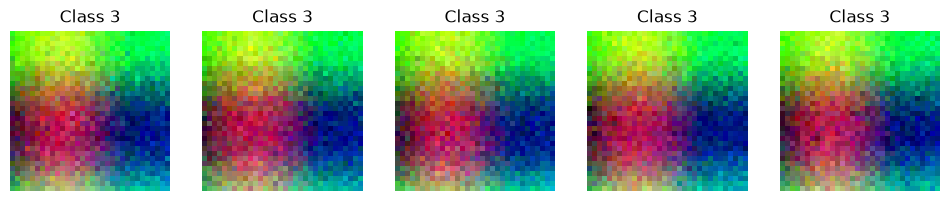

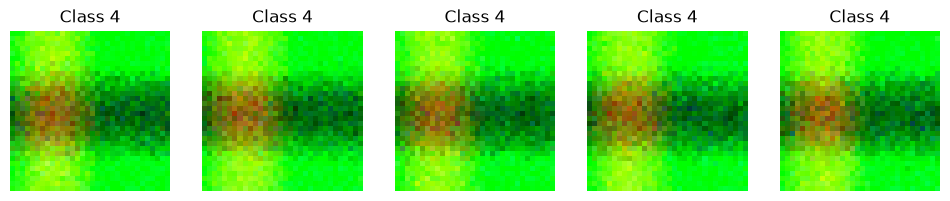

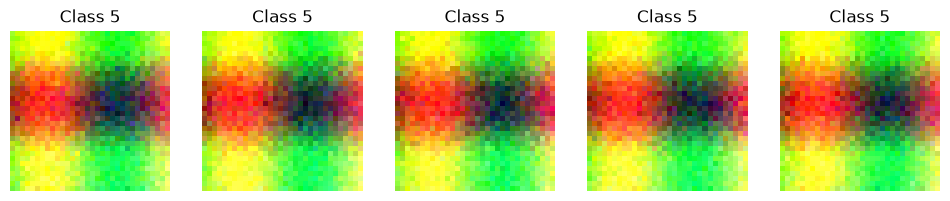

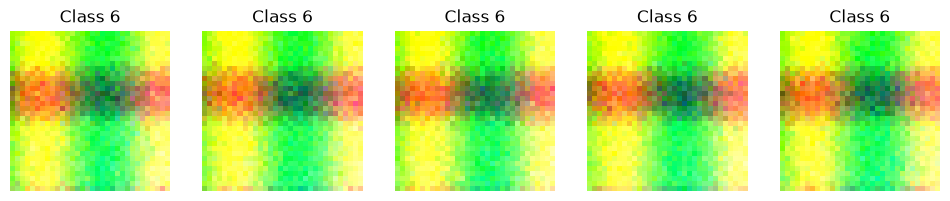

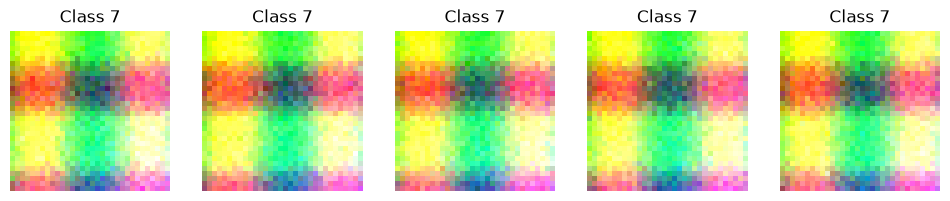

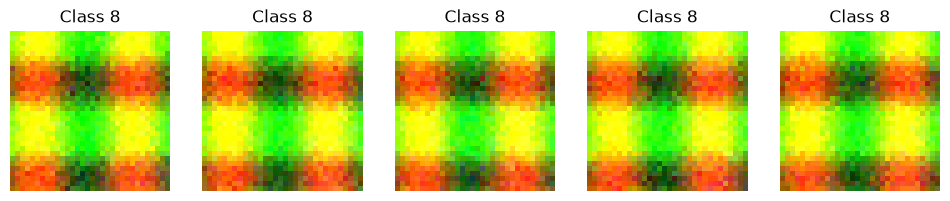

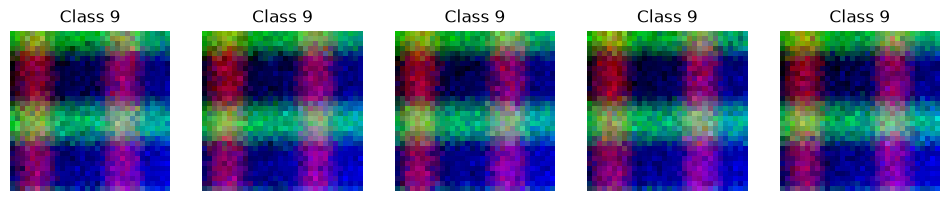

epoch  0  lr 0.0976  train 4.217/0.163  val 132.263/0.278
epoch  1  lr 0.0905  train 1.287/0.299  val 0.542/0.880
epoch  2  lr 0.0794  train 0.935/0.477  val 0.123/1.000
epoch  3  lr 0.0655  train 0.595/0.450  val 0.089/1.000
epoch  4  lr 0.0500  train 0.303/0.521  val 0.258/0.892
epoch  5  lr 0.0345  train 0.470/0.559  val 0.036/1.000
epoch  6  lr 0.0206  train 0.392/0.626  val 0.045/1.000
epoch  7  lr 0.0095  train 0.355/0.511  val 0.022/1.000
epoch  8  lr 0.0024  train 0.334/0.581  val 0.024/1.000
epoch  9  lr 0.0000  train 0.466/0.604  val 0.034/1.000


In [19]:


X, Y = synthetic_cifar(num_per_class=500)
split = int(0.9 * len(X))
X_train, Y_train = X[:split], Y[:split]
X_val, Y_val = X[split:], Y[split:]

mean = [0.5, 0.5, 0.5]
std = [0.25, 0.25, 0.25]
train_tf = compose(random_hflip(), random_crop(pad=4), standardize(mean, std))
eval_tf = standardize(mean, std)

train_ds = ArrayDataset(X_train, Y_train, transform=train_tf)
val_ds = ArrayDataset(X_val, Y_val, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0)

device = "mps"
# torchvision ResNet-18，改成适合 32x32（CIFAR 风格）
from torchvision import models

model = models.resnet18(weights=None, num_classes=10)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()  # 32x32 上不要再提前下采样
model = model.to(device)

optimizer = SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

for epoch in range(10):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, device, 10, use_mixup=True)
    va_loss, va_acc, _ = evaluate(model, val_loader, device, 10)
    scheduler.step()
    print(f"epoch {epoch:2d}  lr {scheduler.get_last_lr()[0]:.4f}  "
          f"train {tr_loss:.3f}/{tr_acc:.3f}  val {va_loss:.3f}/{va_acc:.3f}")

# Instruction Data

* device = "cpu"     13m18s
* device = "mps"     1m46s